In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

### Applying any statistical technique on the same column to fill the missing values in it then this is called univariant imputation
Used when the missing data is less than 5% and is missing completely at random

In [30]:
df = pd.read_csv('titanic_toy.csv')
df.sample(5)

,Age,Fare,Family,Survived
71,16.0,46.9000,7,0
229,NaN,NaN,4,0
127,24.0,7.1417,0,1
867,31.0,50.4958,0,0
810,26.0,7.8875,0,0


In [3]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [4]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [31]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [33]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [8]:
X_train.isnull().mean() * 100

Age       20.786517
Fare       5.056180
Family     0.000000
dtype: float64

In [9]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [10]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

In [11]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
596,NaN,33.0000,0,29.785904,28.75,33.0000,33.0000
210,24.0,7.0500,0,24.000000,24.00,7.0500,7.0500
180,NaN,69.5500,10,29.785904,28.75,69.5500,69.5500
792,NaN,69.5500,10,29.785904,28.75,69.5500,69.5500
31,NaN,146.5208,1,29.785904,28.75,146.5208,146.5208


In [12]:
print('Original Age column variance: ',X_train['Age'].var())
print('Age column variance after mean Imputation: ',X_train['Age_mean'].var())
print('Age column variance after median Imputation: ',X_train['Age_median'].var())

print('Original Fare column variance: ',X_train['Fare'].var())
print('Fare column variance after mean Imputation: ',X_train['Fare_mean'].var())
print('Fare column variance after median Imputation: ',X_train['Fare_median'].var())

Original Age column variance:  204.34951339046142
Age column variance after mean Imputation:  161.81262452718676
Age column variance after median Imputation:  161.98956633460548
Original Fare column variance:  2448.1979137063163
Fare column variance after mean Imputation:  2324.2385256705534
Fare column variance after median Imputation:  2340.09102197536


<Axes: ylabel='Density'>

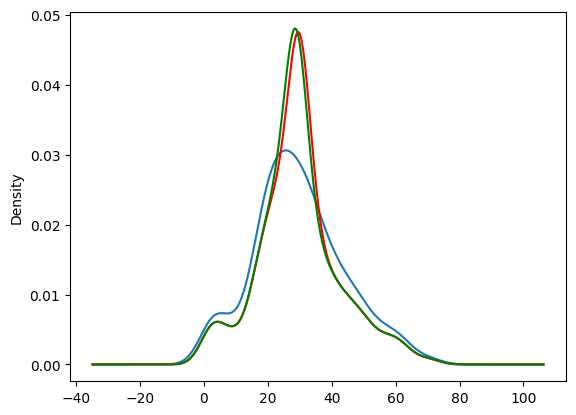

In [13]:
X_train['Age'].plot(kind='kde')
X_train['Age_mean'].plot(kind='kde',color='red')
X_train['Age_median'].plot(kind='kde',color='green')

<Axes: ylabel='Density'>

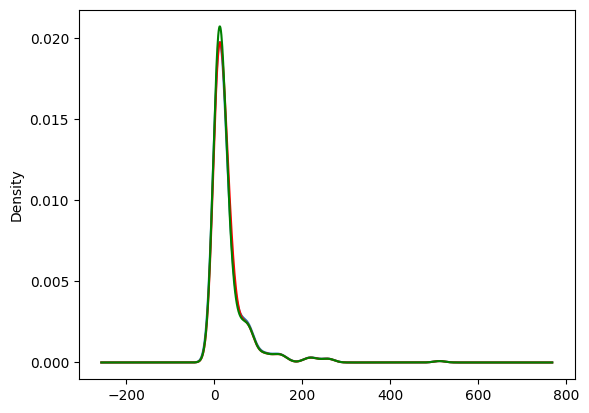

In [14]:
X_train['Fare'].plot(kind='kde')
X_train['Fare_mean'].plot(kind='kde',color='red')
X_train['Fare_median'].plot(kind='kde',color='green')

In [15]:
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.476305
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
Age_median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,53.553455
Fare_mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
Fare_median,64.858859,2448.197914,16.476305,51.358000,53.553455,2324.238526,2340.091022


In [16]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.087356
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205942
Age_mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.083461
Age_median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.086982
Fare_mean,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,0.996607
Fare_median,0.087356,1.000000,0.205942,0.083461,0.086982,0.996607,1.000000


<Axes: >

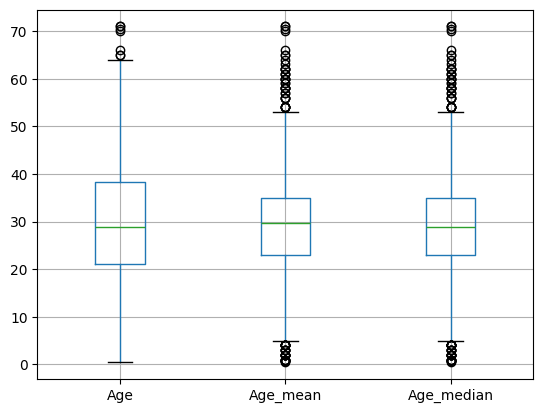

In [17]:
X_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

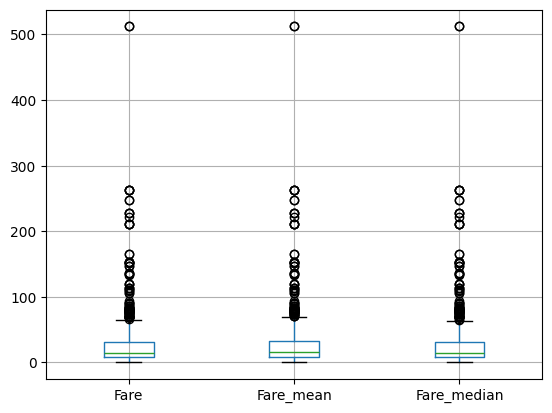

In [18]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

# Imputation using SKLearn:

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [20]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [21]:
trf = ColumnTransformer([
    ('imputer1',imputer2, ['Age']),
    ('imputer2',imputer1, ['Fare'])
],remainder='passthrough')

In [22]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [23]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [24]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [25]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)


In [26]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

# Arbitrary Value Imputation:
Fills each missing value with a value **randomly sampled from the existing (non-missing) distribution** of that same column.

- Preserves the original variance/distribution shape better than mean/median imputation, since you're not collapsing everything to a single point.
- Introduces randomness, so results can vary between runs (should set a random seed for reproducibility).

In [27]:
df.sample(5)

,Age,Fare,Family,Survived
505,18.0,108.900,1,0
190,32.0,13.000,0,1
153,40.5,14.500,2,0
2,26.0,7.925,0,1
452,30.0,27.750,0,0


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [34]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [36]:
X_train.head()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
30,40.0,27.7208,0,40.0,40.0,27.7208,27.7208
10,4.0,16.7000,2,4.0,4.0,16.7000,16.7000
873,47.0,9.0000,0,47.0,47.0,9.0000,9.0000
182,9.0,31.3875,6,9.0,9.0,31.3875,31.3875
876,20.0,9.8458,0,20.0,20.0,9.8458,9.8458


In [37]:
print('Original Age column variance: ',X_train['Age'].var())
print('Age column variance after arbitrary Imputation of 99: ',X_train['Age_99'].var())
print('Age column variance after arbitrary Imputation of -1: ',X_train['Age_minus1'].var())

print('Original Fare column variance: ',X_train['Fare'].var())
print('Fare column variance after arbitrary Imputation of 999: ',X_train['Fare_999'].var())
print('Fare column variance after marbitrry Imputation of -1: ',X_train['Fare_minus1'].var())

Original Age column variance:  204.34951339046142
Age column variance after arbitrary Imputation of 99:  951.7275570187188
Age column variance after arbitrary Imputation of -1:  318.0896202624488
Original Fare column variance:  2448.1979137063163
Fare column variance after arbitrary Imputation of 999:  47219.202652176304
Fare column variance after marbitrry Imputation of -1:  2378.5676784883494


<Axes: ylabel='Density'>

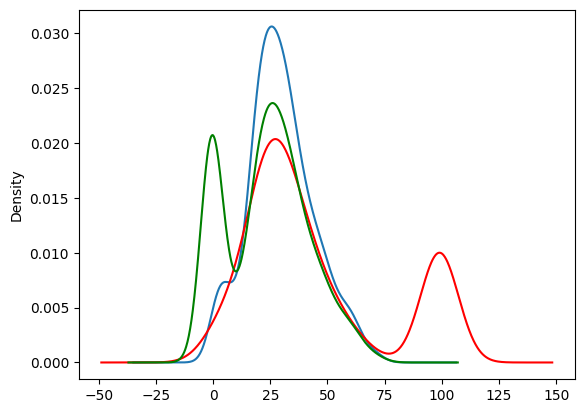

In [38]:
X_train['Age'].plot(kind='kde')
X_train['Age_99'].plot(kind='kde',color='red')
X_train['Age_minus1'].plot(kind='kde',color='green')

<Axes: ylabel='Density'>

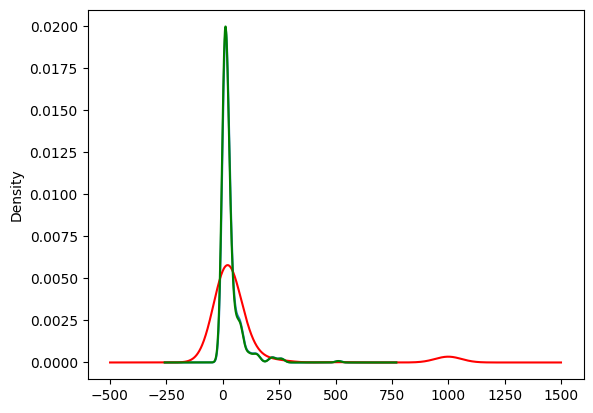

In [39]:
X_train['Fare'].plot(kind='kde')
X_train['Fare_999'].plot(kind='kde',color='red')
X_train['Fare_minus1'].plot(kind='kde',color='green')

In [40]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [41]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


##### This technique is used when the data is not missing at random. This just tells the model that the data is missing here. We can do the same using SKLearn as well like the mean and median imputation.

# End of Distribution Imputation:
Fills missing values with a value **far out in the tail** of the distribution (e.g., mean + 3×std, or the 99th percentile).

$$
x_{missing} = \bar{x} + 3\sigma
$$

- The idea: explicitly flags "this was missing" by pushing it to an extreme, distinguishable value — useful when missingness itself might carry information (i.e., **Missing Not At Random**, MNAR) and you want the model to be able to treat "missing" as its own distinct signal.
- Downside: can create artificial outliers that distort distance-based models (KNN, SVM) or skew scaling if applied after imputation.

In [42]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [49]:
age_std = X_train['Age'].std()
age_mean = X_train['Age'].mean()
age_eod = age_mean + (3 * age_std)

fare_std = X_train['Fare'].std()
fare_mean = X_train['Fare'].mean()
fare_eod = fare_mean + (3 * fare_std)

In [50]:
X_train['Age_EOD'] = X_train['Age'].fillna(age_eod)
X_train['Fare_EOD'] = X_train['Fare'].fillna(fare_eod)

In [51]:
X_train.head()

,Age,Fare,Family,Age_EOD,Fare_EOD
30,40.0,27.7208,0,40.0,27.7208
10,4.0,16.7000,2,4.0,16.7000
873,47.0,9.0000,0,47.0,9.0000
182,9.0,31.3875,6,9.0,31.3875
876,20.0,9.8458,0,20.0,9.8458


In [52]:
print('Original Age column variance: ',X_train['Age'].var())
print('Age column variance after end of distribution Imputation: ',X_train['Age_EOD'].var())

print('Original Fare column variance: ',X_train['Fare'].var())
print('Fare column variance after end of distribution Imputation of 999: ',X_train['Fare_EOD'].var())

Original Age column variance:  204.34951339046142
Age column variance after end of distribution Imputation:  465.06718614233046
Original Fare column variance:  2448.1979137063163
Fare column variance after end of distribution Imputation of 999:  3383.4645324255835


<Axes: ylabel='Density'>

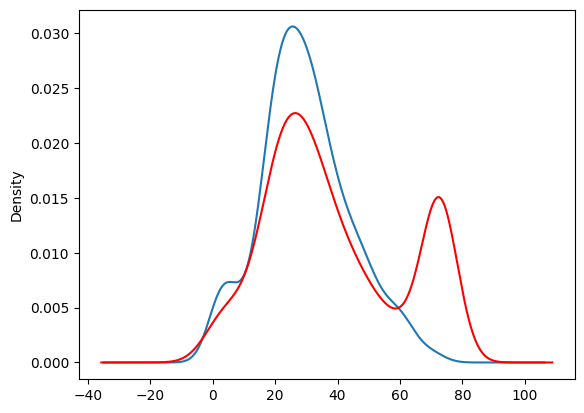

In [53]:
X_train['Age'].plot(kind='kde')
X_train['Age_EOD'].plot(kind='kde',color='red')

<Axes: ylabel='Density'>

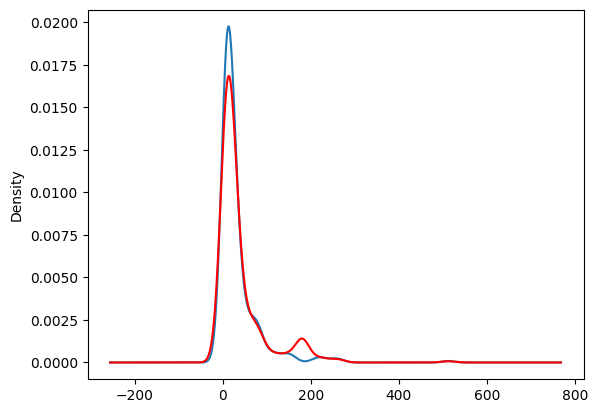

In [54]:
X_train['Fare'].plot(kind='kde')
X_train['Fare_EOD'].plot(kind='kde',color='red')

<Axes: >

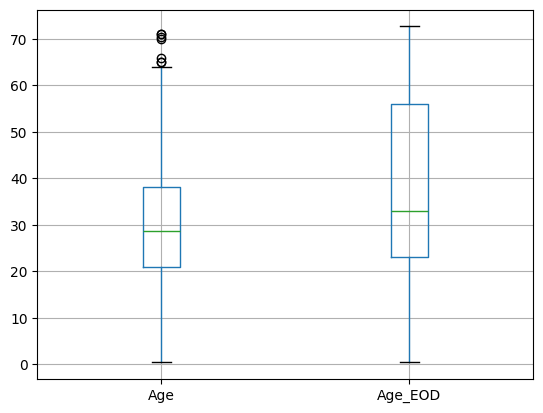

In [56]:
X_train[['Age','Age_EOD']].boxplot()

<Axes: >

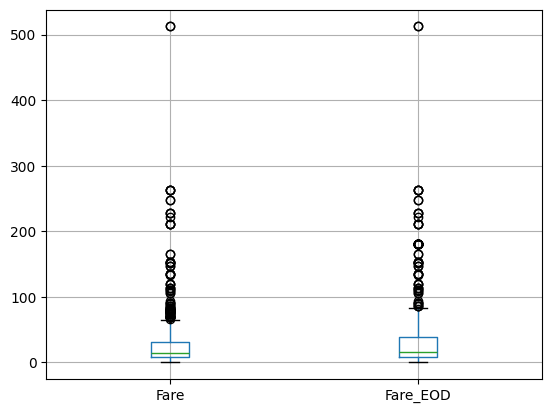

In [57]:
X_train[['Fare','Fare_EOD']].boxplot()

##### This technique is used when the data is not missing at random. This just tells the model that the data is missing here. We can do the same using SKLearn as well like the mean and median imputation.